# Sanity Check - Step 02: Common Average Reference (CAR)

Überprüft:
- Re-Referenzing zu Common Average erfolgreich
- Vorher/Nachher Vergleich
- Signal-Qualität nach CAR

In [1]:
import sys
import mne
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / 'eeg_pipeline'))
import config

print("Setup erfolgreich")

Setup erfolgreich


## 1. VORHER: Renamed Raw Daten (Step 01 Output)

In [2]:
subject_id = config.SUBJECTS[0]

# Step 01 Output laden (VORHER)
p1_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P1_renamed_raw.fif"
p2_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P2_renamed_raw.fif"

raw_p1_before = mne.io.read_raw_fif(str(p1_path_before), preload=False)
raw_p2_before = mne.io.read_raw_fif(str(p2_path_before), preload=False)

print(f"\n=== VORHER (Step 01 Output) ===\n")
print(f"Person 1:")
print(f"  Projekt: {raw_p1_before.info['proj_id']}")
print(f"  Ref-Status: {raw_p1_before.info['custom_ref_applied']}")
print(f"  Channel types: EEG={len(mne.pick_types(raw_p1_before.info, eeg=True))}")

print(f"\nPerson 2:")
print(f"  Projekt: {raw_p2_before.info['proj_id']}")
print(f"  Ref-Status: {raw_p2_before.info['custom_ref_applied']}")
print(f"  Channel types: EEG={len(mne.pick_types(raw_p2_before.info, eeg=True))}")

Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_renamed_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== VORHER (Step 01 Output) ===

Person 1:
  Projekt: None
  Ref-Status: 0 (FIFFV_MNE_CUSTOM_REF_OFF)
  Channel types: EEG=64

Person 2:
  Projekt: None
  Ref-Status: 0 (FIFFV_MNE_CUSTOM_REF_OFF)
  Channel types: EEG=64


## 2. NACHHER: CAR Re-referenced Raw Daten (Step 02 Output)

In [3]:
# Step 02 Output laden (NACHHER)
p1_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P1_renamed_raw_CAR_raw.fif"
p2_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P2_renamed_raw_CAR_raw.fif"

raw_p1_after = mne.io.read_raw_fif(str(p1_path_after), preload=False)
raw_p2_after = mne.io.read_raw_fif(str(p2_path_after), preload=False)

print(f"\n=== NACHHER (Step 02 Output) ===\n")
print(f"Person 1:")
print(f"  Projekt: {raw_p1_after.info['proj_id']}")
print(f"  Ref-Status: {raw_p1_after.info['custom_ref_applied']}")
print(f"  Channel types: EEG={len(mne.pick_types(raw_p1_after.info, eeg=True))}")

print(f"\nPerson 2:")
print(f"  Projekt: {raw_p2_after.info['proj_id']}")
print(f"  Ref-Status: {raw_p2_after.info['custom_ref_applied']}")
print(f"  Channel types: EEG={len(mne.pick_types(raw_p2_after.info, eeg=True))}")

Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw_CAR_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_renamed_raw_CAR_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== NACHHER (Step 02 Output) ===

Person 1:
  Projekt: None
  Ref-Status: 1
  Channel types: EEG=64

Person 2:
  Projekt: None
  Ref-Status: 1
  Channel types: EEG=64


## 3. Amplituden Vergleich: VORHER vs. NACHHER

In [4]:
# Hole EEG Daten
eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)
raw_p1_before.load_data()
raw_p1_after.load_data()
data_before = raw_p1_before.get_data(picks=eeg_picks)
data_after = raw_p1_after.get_data(picks=eeg_picks)

print(f"\n=== AMPLITUDEN VERGLEICH (Person 1) ===\n")

print(f"VORHER (Step 01):")
print(f"  Shape: {data_before.shape}")
print(f"  Min: {np.min(data_before):.6f} µV")
print(f"  Max: {np.max(data_before):.6f} µV")
print(f"  Mean: {np.mean(data_before):.6f} µV")
print(f"  Std: {np.std(data_before):.6f} µV")
print(f"  RMS: {np.sqrt(np.mean(data_before**2)):.6f} µV")

print(f"\nNACHHER (Step 02 - CAR):")
print(f"  Shape: {data_after.shape}")
print(f"  Min: {np.min(data_after):.6f} µV")
print(f"  Max: {np.max(data_after):.6f} µV")
print(f"  Mean: {np.mean(data_after):.6f} µV")
print(f"  Std: {np.std(data_after):.6f} µV")
print(f"  RMS: {np.sqrt(np.mean(data_after**2)):.6f} µV")

print(f"\nÄNDERUNG:")
print(f"  Amplitude Reduktion (Std): {(1 - np.std(data_after)/np.std(data_before))*100:.2f}%")
print(f"  Amplitude Reduktion (RMS): {(1 - np.sqrt(np.mean(data_after**2))/np.sqrt(np.mean(data_before**2)))*100:.2f}%")

Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...

=== AMPLITUDEN VERGLEICH (Person 1) ===

VORHER (Step 01):
  Shape: (64, 7514112)
  Min: -0.026847 µV
  Max: 0.003377 µV
  Mean: -0.010595 µV
  Std: 0.004670 µV
  RMS: 0.011578 µV

NACHHER (Step 02 - CAR):
  Shape: (64, 7514112)
  Min: -0.014707 µV
  Max: 0.011907 µV
  Mean: -0.000000 µV
  Std: 0.004516 µV
  RMS: 0.004516 µV

ÄNDERUNG:
  Amplitude Reduktion (Std): 3.30%
  Amplitude Reduktion (RMS): 61.00%


## 4. PSD Vergleich: VORHER vs. NACHHER

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


C:\Users\bk57s\AppData\Local\Temp\ipykernel_4032\3971504358.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


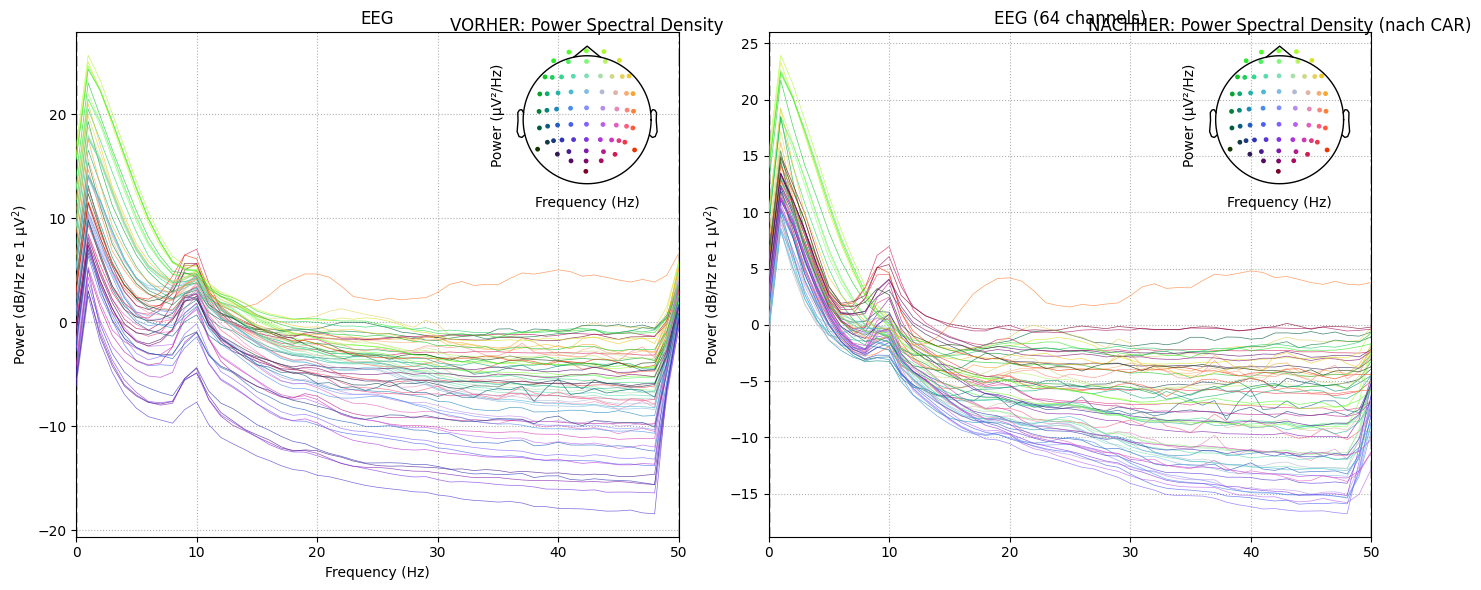

In [5]:
# PSD plotten
fig = plt.figure(figsize=(14, 6))

# VORHER
plt.subplot(1, 2, 1)
raw_p1_before_eeg = raw_p1_before.copy().pick_types(eeg=True).load_data()
raw_p1_before_eeg.plot_psd(fmax=50, ax=plt.gca(), show=False)
plt.title('VORHER: Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')

# NACHHER
plt.subplot(1, 2, 2)
raw_p1_after_eeg = raw_p1_after.copy().pick_types(eeg=True).load_data()
raw_p1_after_eeg.plot_psd(fmax=50, ax=plt.gca(), show=False)
plt.title('NACHHER: Power Spectral Density (nach CAR)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')

plt.tight_layout()
plt.show()

## 5. Topographische Spannungsmaps

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


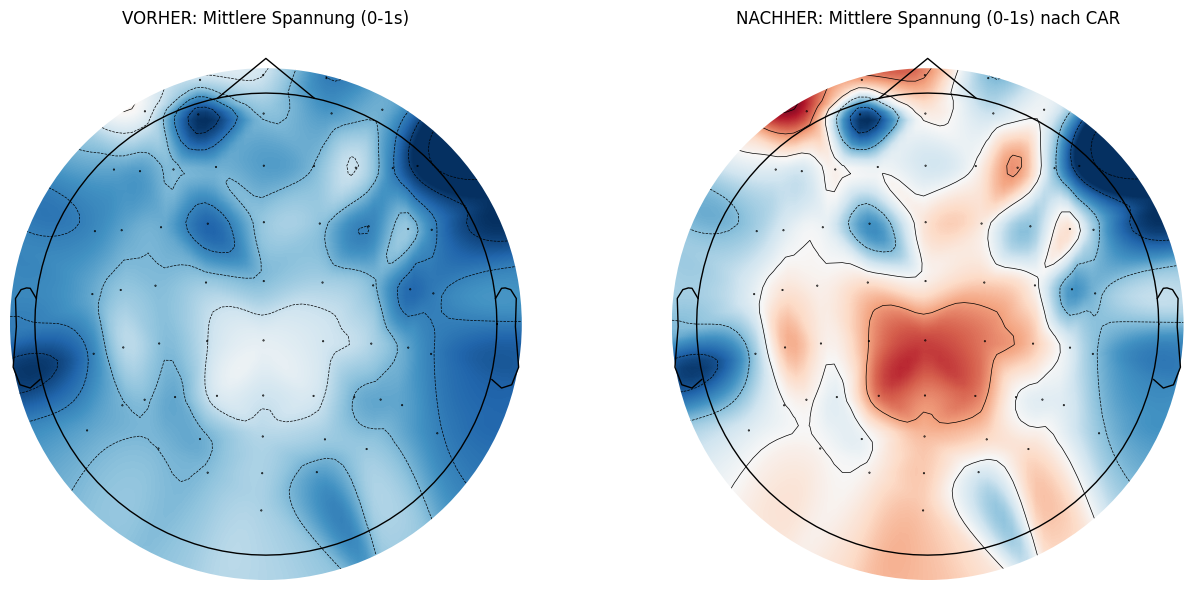

In [6]:
# Erstelle eine Epoche für Topomap-Visualisierung
# Nutze einen kurzen Zeitpunkt
tmin_topo, tmax_topo = 0, 1  # 1 Sekunde

t_idx_start = int(tmin_topo * raw_p1_before.info['sfreq'])
t_idx_end = int(tmax_topo * raw_p1_before.info['sfreq'])

eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)
data_topo_before = raw_p1_before.get_data(picks=eeg_picks)[:, t_idx_start:t_idx_end].mean(axis=1)
data_topo_after = raw_p1_after.get_data(picks=eeg_picks)[:, t_idx_start:t_idx_end].mean(axis=1)

# Erstelle Info für Topomap
info_eeg = raw_p1_before.copy().pick_types(eeg=True).info

fig = plt.figure(figsize=(14, 6))

# VORHER
ax1 = plt.subplot(1, 2, 1)
mne.viz.plot_topomap(data_topo_before, info_eeg, axes=ax1, show=False, cmap='RdBu_r')
ax1.set_title('VORHER: Mittlere Spannung (0-1s)')

# NACHHER
ax2 = plt.subplot(1, 2, 2)
mne.viz.plot_topomap(data_topo_after, info_eeg, axes=ax2, show=False, cmap='RdBu_r')
ax2.set_title('NACHHER: Mittlere Spannung (0-1s) nach CAR')

plt.tight_layout()
plt.show()

## 6. Kanal-zu-Kanal Differenzen

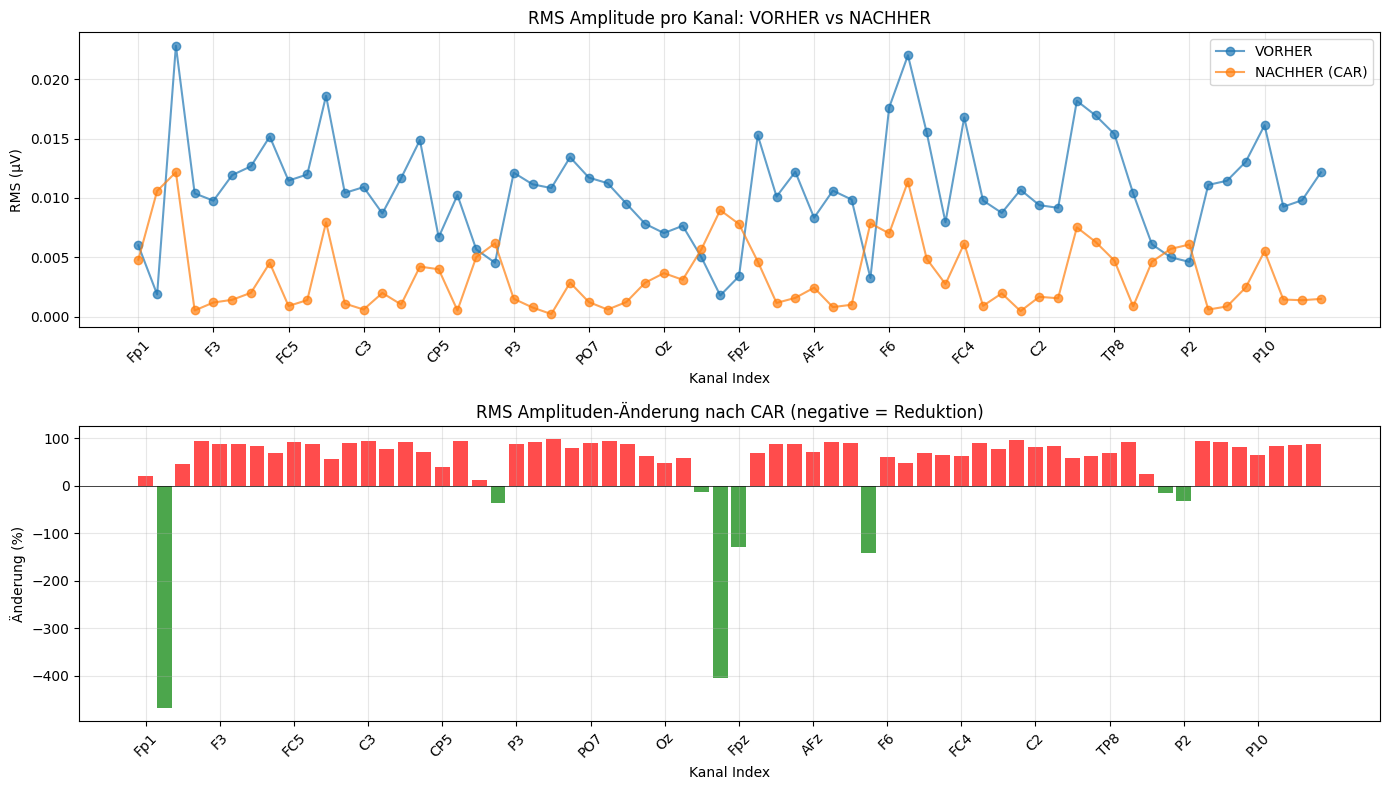


RMS Änderung pro Kanal (Mittelwert): 46.78%
RMS Änderung Range: -467.65% bis 98.05%


In [7]:
# Berechne RMS Änderung pro Kanal
rms_before = np.sqrt(np.mean(data_before**2, axis=1))
rms_after = np.sqrt(np.mean(data_after**2, axis=1))
rms_change = ((rms_before - rms_after) / rms_before) * 100

eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)
ch_names = np.array(raw_p1_before.ch_names)[eeg_picks]

# Visualisierung
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# RMS VORHER vs NACHHER
ax1 = axes[0]
x = np.arange(len(ch_names))
ax1.plot(x, rms_before, 'o-', label='VORHER', alpha=0.7)
ax1.plot(x, rms_after, 'o-', label='NACHHER (CAR)', alpha=0.7)
ax1.set_xlabel('Kanal Index')
ax1.set_ylabel('RMS (µV)')
ax1.set_title('RMS Amplitude pro Kanal: VORHER vs NACHHER')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x[::4])
ax1.set_xticklabels(ch_names[::4], rotation=45)

# RMS ÄNDERUNG in %
ax2 = axes[1]
colors = ['green' if c < 0 else 'red' for c in rms_change]
ax2.bar(x, rms_change, color=colors, alpha=0.7)
ax2.set_xlabel('Kanal Index')
ax2.set_ylabel('Änderung (%)')
ax2.set_title('RMS Amplituden-Änderung nach CAR (negative = Reduktion)')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x[::4])
ax2.set_xticklabels(ch_names[::4], rotation=45)

plt.tight_layout()
plt.show()

print(f"\nRMS Änderung pro Kanal (Mittelwert): {np.mean(rms_change):.2f}%")
print(f"RMS Änderung Range: {np.min(rms_change):.2f}% bis {np.max(rms_change):.2f}%")

## 7. Person 1 vs Person 2 Vergleich

In [8]:
# Prüfe Person 2 - compute statistics without loading all data
eeg_picks_p2 = mne.pick_types(raw_p2_before.info, eeg=True)

print(f"\n=== PERSON 2 STATISTIKEN ===\n")

# Compute BEFORE stats by processing channel-by-channel
p2_before_stds = []
p2_before_rms = []

for pick_idx in eeg_picks_p2:
    ch_data = raw_p2_before.get_data(picks=[pick_idx])  # Load only one channel
    p2_before_stds.append(np.std(ch_data))
    p2_before_rms.append(np.sqrt(np.mean(ch_data**2)))

p2_std_before = np.mean(p2_before_stds)
p2_rms_before = np.mean(p2_before_rms)

print(f"VORHER:")
print(f"  Std (avg across channels): {p2_std_before:.6f} µV")
print(f"  RMS (avg across channels): {p2_rms_before:.6f} µV")

# Compute AFTER stats by processing channel-by-channel
p2_after_stds = []
p2_after_rms = []

for pick_idx in eeg_picks_p2:
    ch_data = raw_p2_after.get_data(picks=[pick_idx])  # Load only one channel
    p2_after_stds.append(np.std(ch_data))
    p2_after_rms.append(np.sqrt(np.mean(ch_data**2)))

p2_std_after = np.mean(p2_after_stds)
p2_rms_after = np.mean(p2_after_rms)

print(f"\nNACHHER (CAR):")
print(f"  Std (avg across channels): {p2_std_after:.6f} µV")
print(f"  RMS (avg across channels): {p2_rms_after:.6f} µV")

print(f"\nÄNDERUNG:")
print(f"  Amplitude Reduktion (Std): {(1 - p2_std_after/p2_std_before)*100:.2f}%")
print(f"  Amplitude Reduktion (RMS): {(1 - p2_rms_after/p2_rms_before)*100:.2f}%")


=== PERSON 2 STATISTIKEN ===

VORHER:
  Std (avg across channels): 0.001241 µV
  RMS (avg across channels): 0.004084 µV

NACHHER (CAR):
  Std (avg across channels): 0.000716 µV
  RMS (avg across channels): 0.003717 µV

ÄNDERUNG:
  Amplitude Reduktion (Std): 42.32%
  Amplitude Reduktion (RMS): 8.98%


## 8. Zusammenfassung & Validierung

In [10]:
print(f"\n=== SANITY CHECK ZUSAMMENFASSUNG ===\n")

checks = []

# 1. Daten-Shape sollte gleich sein
same_shape = data_before.shape == data_after.shape
checks.append(("Daten-Shape gleich", same_shape))

# 2. Kanal-Namen sollten gleich sein
same_channels = raw_p1_before.ch_names == raw_p1_after.ch_names
checks.append(("Kanal-Namen gleich", same_channels))

# 3. CAR sollte Amplitude reduzieren (etwas)
amp_reduced = np.std(data_after) < np.std(data_before)
checks.append(("Amplitude reduziert", amp_reduced))

# 4. CAR sollte nicht zu viel Amplitude reduzieren
amp_reduction_reasonable = (np.std(data_before) - np.std(data_after)) / np.std(data_before) < 0.5  # Weniger als 50%
checks.append(("Amplitude-Reduktion vernünftig (< 50%)", amp_reduction_reasonable))

# 5. Keine NaN oder Inf
no_nan_inf = not (np.isnan(data_after).any() or np.isinf(data_after).any())
checks.append(("Keine NaN/Inf Werte", no_nan_inf))

# 6. Sampling Rate gleich
same_sfreq = raw_p1_before.info['sfreq'] == raw_p1_after.info['sfreq']
checks.append(("Sampling Rate gleich", same_sfreq))

# 7. Person 2 auch bearbeitet (basierend auf berechneten Statistiken)
p2_processed = p2_std_after < p2_std_before
checks.append(("Person 2 auch CAR angewendet", p2_processed))

for check_name, result in checks:
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"{status}: {check_name}")

all_pass = all(result for _, result in checks)
print(f"\n{'='*50}")
if all_pass:
    print("✓ ALLE CHECKS BESTANDEN")
else:
    print("✗ EINIGE CHECKS FEHLGESCHLAGEN")
print(f"{'='*50}")


=== SANITY CHECK ZUSAMMENFASSUNG ===

✓ PASS: Daten-Shape gleich
✓ PASS: Kanal-Namen gleich
✓ PASS: Amplitude reduziert
✓ PASS: Amplitude-Reduktion vernünftig (< 50%)
✓ PASS: Keine NaN/Inf Werte
✓ PASS: Sampling Rate gleich
✓ PASS: Person 2 auch CAR angewendet

✓ ALLE CHECKS BESTANDEN
